# Build mechanism result tables

This orchestrator builds three separate outputs: Volt-VAr net-meter-proxy results, Volt-Watt net-meter-proxy results, and response observability. It never combines them into one score.

Counterfactual-supported curtailment is intentionally not built: load-PV decomposition and its uncertainty validation have not passed methodology gate 7.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

HERE = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'src' / 'ausgrid_analysis').is_dir()), None)
assert PROJECT_ROOT is not None, 'Start Jupyter inside the ausgrid_analysis project.'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from ausgrid_analysis.as4777_curves import (
    VOLT_VAR, VOLT_WATT, vvar_required_q, vvar_required_q_sql,
    vw_max_p, vw_max_p_sql,
)
from ausgrid_analysis.config import load_config
from ausgrid_analysis.db import connect
from ausgrid_analysis.mechanism_config import load_mechanism_config
from ausgrid_analysis.mechanism_paths import (
    response_observability_path, sign_candidate_days_path,
    sign_phase_intervals_path, sign_site_intervals_path,
    voltvar_results_path, voltwatt_results_path,
)
from ausgrid_analysis.mechanism_results import (
    build_response_observability, build_voltvar_results, build_voltwatt_results,
)
from ausgrid_analysis.mechanism_validation import validate_mechanism_results
from ausgrid_analysis.schemas import sql_string
from ausgrid_analysis.sign_diagnostics import build_sign_diagnostics

CONFIG_PATH = PROJECT_ROOT / 'analysis.toml'
config = load_config(CONFIG_PATH, check_inputs=True)
mechanism = load_mechanism_config(CONFIG_PATH)
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')


## Stage 0 — methodology readiness

The configured voltage is the maximum across inferred DER phases. This is a conservative high-voltage exposure choice, not a claim about the inverter's internal control logic. Per-phase and min/mean/max voltage remain in the structured source. The only permitted capacity basis is verified `s_rated_kva`; null ratings remain not assessable.


In [2]:
methodology = pd.Series({
    'methodology_id': mechanism.methodology_id,
    'voltage_aggregate': mechanism.voltage_aggregate,
    'voltage_basis': mechanism.voltage_basis_label,
    'capacity_basis': mechanism.capacity_basis,
    'active_sign_review_state': mechanism.active_sign_review_state,
    'reactive_sign_review_state': mechanism.reactive_sign_review_state,
    'measurement_basis': 'net_meter_proxy',
    'voltage_location': 'revenue_meter',
    'curtailment': 'not_built_gate_7_unmet',
}, name='value')
display(methodology.to_frame())
assert mechanism.capacity_basis == 's_rated_kva'
assert mechanism.voltage_aggregate in {'avg', 'max'}


,value
methodology_id,net_meter_proxy__voltage_avg__capacity_s_rated...
voltage_aggregate,avg
voltage_basis,mean_inferred_der_phase_revenue_meter_voltage
capacity_basis,s_rated_kva
active_sign_review_state,unverified
reactive_sign_review_state,unverified
measurement_basis,net_meter_proxy
voltage_location,revenue_meter
curtailment,not_built_gate_7_unmet


## Stage 1 — empirical P/Q sign review

This stage selects 2–3 deterministic solar-only, no-battery, no-controlled-load site-days from the configured month. Selection uses high-voltage exposure and positive derived net export, not the desired response direction. Inspect raw and derived P/Q. At high voltage, generator-convention Q should move negative for absorption. If either hypothesis is contradicted, stop, correct the foundation sign configuration, and rebuild affected canonical/structured outputs before continuing. Ausgrid confirmation is still required.


In [3]:
OVERWRITE_SIGN_DIAGNOSTICS = True
sign_paths_exist = all(p.is_file() for p in (
    sign_candidate_days_path(config), sign_site_intervals_path(config),
    sign_phase_intervals_path(config),
))
if OVERWRITE_SIGN_DIAGNOSTICS or not sign_paths_exist:
    sign_summary = build_sign_diagnostics(config, mechanism, overwrite=OVERWRITE_SIGN_DIAGNOSTICS)
    display(pd.DataFrame([sign_summary]).T.rename(columns={0: 'value'}))
else:
    print('Reusing sign diagnostics. Set OVERWRITE_SIGN_DIAGNOSTICS=True to rebuild.')
con = connect(config)
candidate_days = con.execute(f'SELECT * FROM read_parquet({sql_string(sign_candidate_days_path(config))})').fetchdf()
sign_site = con.execute(f'SELECT * FROM read_parquet({sql_string(sign_site_intervals_path(config))}) ORDER BY serial, timestamp_utc').fetchdf()
sign_phase = con.execute(f'SELECT * FROM read_parquet({sql_string(sign_phase_intervals_path(config))}) ORDER BY serial, timestamp_utc, phase').fetchdf()
con.close()
display(candidate_days)
display(sign_phase[['serial','timestamp_local','phase','voltage_v','active_power_raw_w','p_export_w','reactive_power_raw_var','q_absorbing_var','q_generator_var','is_inferred_der_phase']].head(30))
assert candidate_days.serial.nunique() == mechanism.sign_audit_site_count
assert sign_site.timestamp_utc.notna().all()


,value
created_utc,2026-08-02T02:24:49.193884+00:00
candidate_month,2025-01
candidate_sites,3
site_interval_rows,864
phase_interval_rows,2592
active_contract_errors,0
absorbing_contract_errors,0
generator_contract_errors,0
active_sign_review_state,unverified
reactive_sign_review_state,unverified


,serial,local_date,n_day_intervals,minimum_voltage_v,maximum_voltage_v,n_high_voltage_export_intervals,maximum_export_w
0,810745397,2025-01-25,288,245.039536,255.346146,71.0,6994.12100
1,811187821,2025-01-04,288,241.607437,254.665909,71.0,7826.26855
2,811280075,2025-01-12,288,236.598434,256.613861,65.0,3992.26465


,serial,timestamp_local,phase,voltage_v,active_power_raw_w,p_export_w,reactive_power_raw_var,q_absorbing_var,q_generator_var,is_inferred_der_phase
0,810745397,2025-01-25 00:00:00,A,249.935181,61.262375,-61.262375,-255.259888,255.259888,-255.259888,True
1,810745397,2025-01-25 00:00:00,B,246.327866,20.420792,-20.420792,-15.315594,15.315594,-15.315594,False
2,810745397,2025-01-25 00:00:00,C,245.791916,112.314354,-112.314354,-45.946780,45.946780,-45.946780,False
3,810745397,2025-01-25 00:05:00,A,250.636017,61.262375,-61.262375,-255.259888,255.259888,-255.259888,True
4,810745397,2025-01-25 00:05:00,B,246.637054,20.420792,-20.420792,-15.315594,15.315594,-15.315594,False
5,810745397,2025-01-25 00:05:00,C,244.039800,91.893560,-91.893560,-51.051980,51.051980,-51.051980,False
6,810745397,2025-01-25 00:10:00,A,251.573929,71.472770,-71.472770,-270.575500,270.575500,-270.575500,True
7,810745397,2025-01-25 00:10:00,B,248.306732,20.420792,-20.420792,-15.315594,15.315594,-15.315594,False
8,810745397,2025-01-25 00:10:00,C,243.287415,102.103958,-102.103958,-51.051980,51.051980,-51.051980,False
9,810745397,2025-01-25 00:15:00,A,251.573929,25.525990,-25.525990,-260.365082,260.365082,-260.365082,True


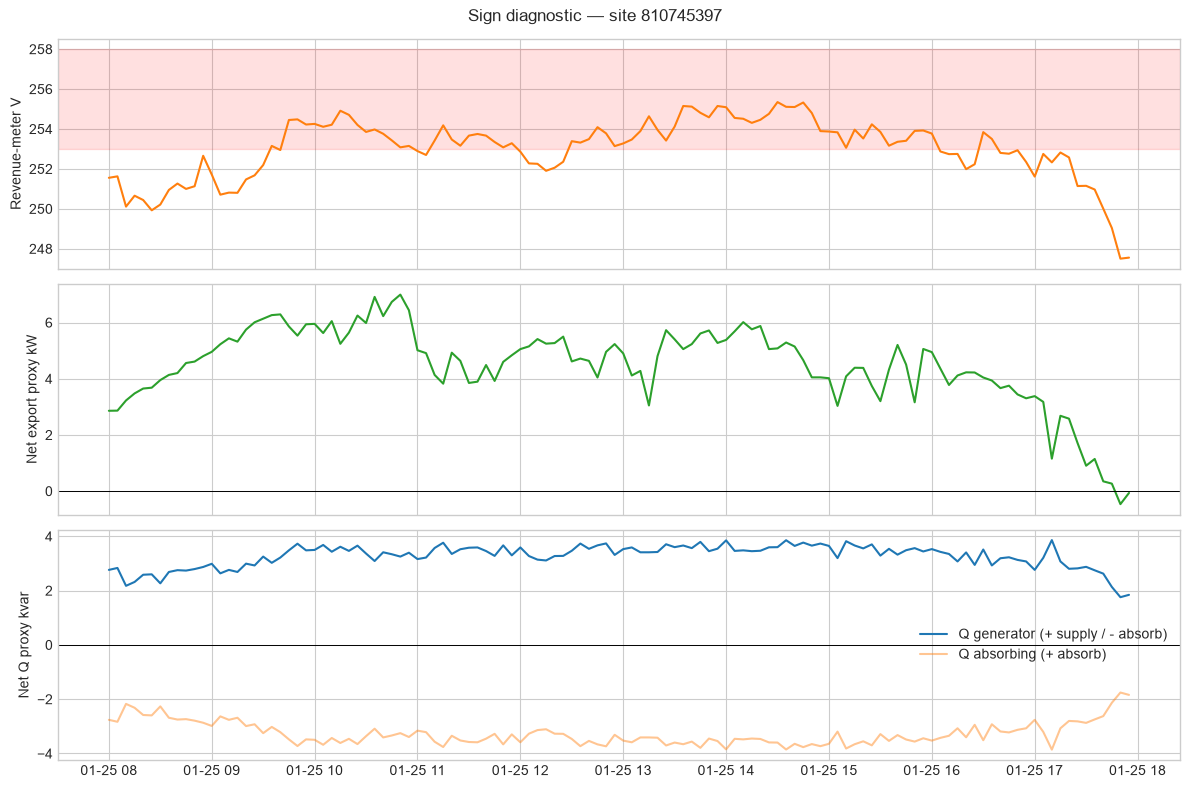

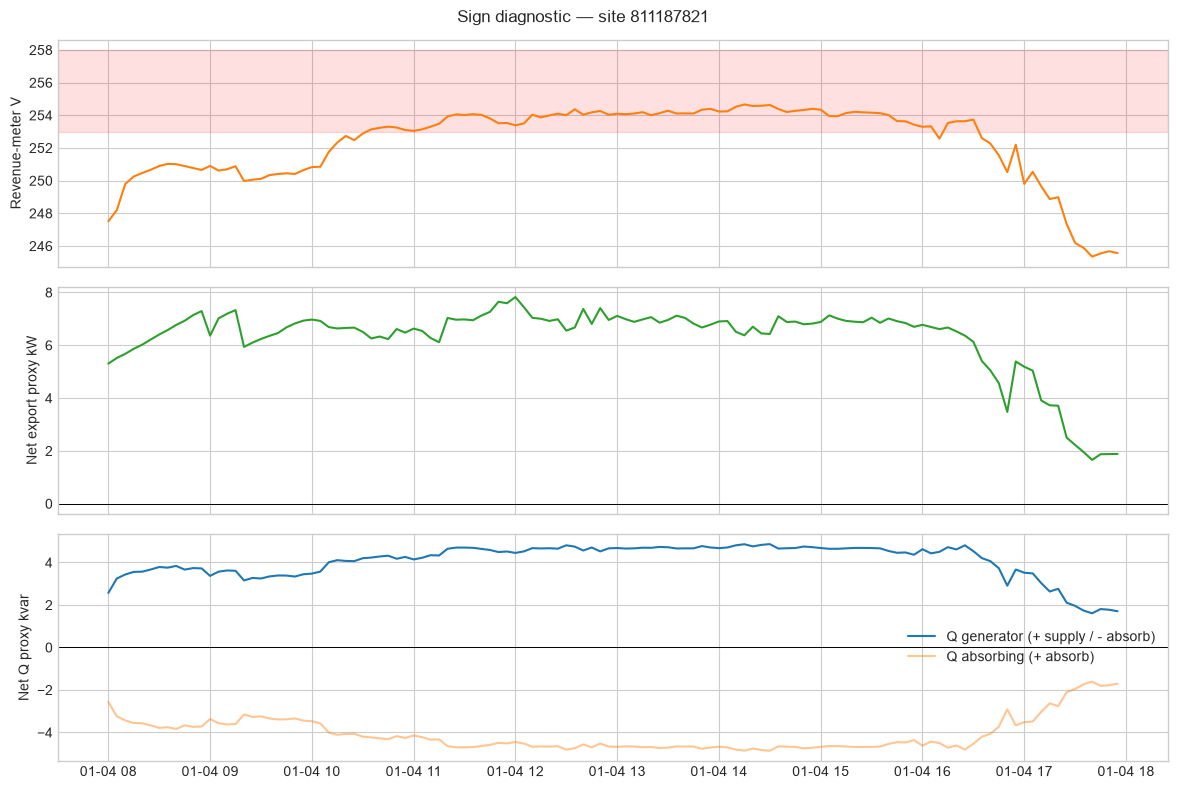

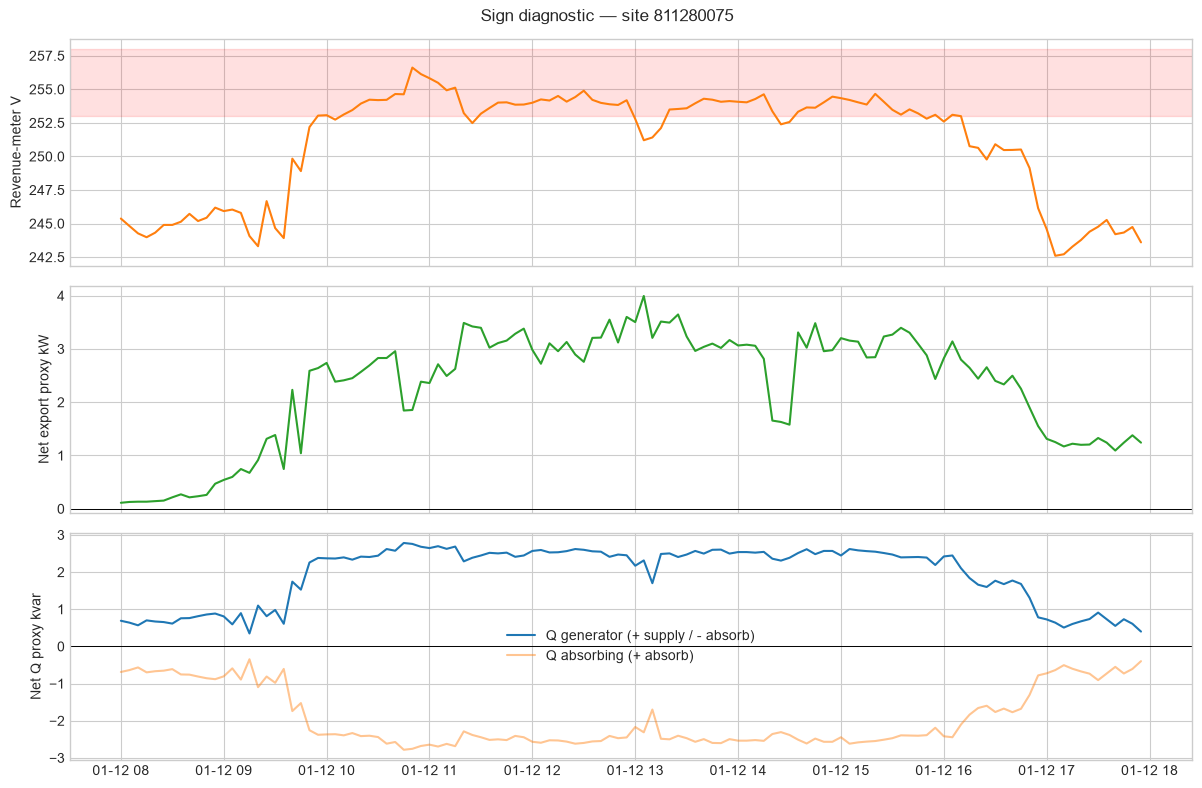

In [4]:
for serial, frame in sign_site.groupby('serial', sort=True):
    daylight = frame.loc[frame.local_hour.between(8, 17)].copy()
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(daylight.timestamp_local, daylight.comparison_voltage_v, color='tab:orange')
    axes[0].axhspan(253, 258, alpha=0.12, color='red')
    axes[0].set_ylabel('Revenue-meter V')
    axes[1].plot(daylight.timestamp_local, daylight.p_export_net_proxy_w / 1000, color='tab:green')
    axes[1].axhline(0, color='black', linewidth=0.7)
    axes[1].set_ylabel('Net export proxy kW')
    axes[2].plot(daylight.timestamp_local, daylight.q_generator_net_proxy_var / 1000, label='Q generator (+ supply / - absorb)')
    axes[2].plot(daylight.timestamp_local, daylight.q_absorbing_net_proxy_var / 1000, alpha=0.45, label='Q absorbing (+ absorb)')
    axes[2].axhline(0, color='black', linewidth=0.7)
    axes[2].set_ylabel('Net Q proxy kvar')
    axes[2].legend()
    fig.suptitle(f'Sign diagnostic — site {serial}')
    plt.tight_layout()
    plt.show()


In [5]:
SIGN_REVIEW_CONFIRMATION = 'BUILD WITH SIGNS UNVERIFIED'
# Review the candidate plots and raw/derived sign table above, then choose
# exactly one of the two documented confirmation strings:
#
#   'SIGN REVIEW COMPLETE'
#       Both active_sign_review_state and reactive_sign_review_state in
#       [mechanism_analysis] must already be a ready state
#       (empirically_supported_pending_provider_confirmation or
#       provider_confirmed). Unlocks assessable magnitude/observability rows.
#
#   'BUILD WITH SIGNS UNVERIFIED'
#       Proceeds with both review states left exactly as configured
#       (currently 'unverified' -- Ausgrid has not confirmed either
#       convention). This does NOT flip, fake, or bypass the sign states: it
#       is a documented, deliberate choice to build the denominator/coverage
#       and observability tables now, with every sign-dependent row labelled
#       'sign_unverified' (mechanism_results.py already implements this --
#       it is the same behaviour a ready-sign build would fall back to for
#       any row failing the sign gate, just applied to every row). No
#       'assessable' proxy curve-status or observability-direction row is
#       produced under this path. Flip the two review states in
#       analysis.toml once Ausgrid confirms (or an empirical review supports
#       a state), then rerun the Stage 3-5 builders with
#       OVERWRITE_SAMPLE/OVERWRITE_FULL=True to rebuild a clean, assessable
#       database. The methodology_id and both review states are stamped on
#       every output row, so a sign_unverified-built table can never be
#       confused with a ready-sign build later.
assert SIGN_REVIEW_CONFIRMATION in {'SIGN REVIEW COMPLETE', 'BUILD WITH SIGNS UNVERIFIED'}, (
    'Review the candidate plots and raw/derived sign table first, then set '
    "SIGN_REVIEW_CONFIRMATION to one of the two documented strings."
)
if SIGN_REVIEW_CONFIRMATION == 'SIGN REVIEW COMPLETE':
    assert mechanism.active_sign_review_state not in {'contradicted', 'inconclusive', 'unverified'}
    assert mechanism.reactive_sign_review_state not in {'contradicted', 'inconclusive', 'unverified'}
    assert mechanism.active_sign_ready and mechanism.reactive_sign_ready, (
        'Record the reviewed states in [mechanism_analysis], restart the kernel, and rerun. '
        'If contradicted, fix analysis.toml signs and rebuild the foundation/structured data first.'
    )
    print('Sign review gate passed; provider confirmation may still be pending.')
else:
    assert mechanism.active_sign_review_state == 'unverified'
    assert mechanism.reactive_sign_review_state == 'unverified'
    assert not (mechanism.active_sign_ready and mechanism.reactive_sign_ready)
    print(
        "Sign review gate passed under 'BUILD WITH SIGNS UNVERIFIED'. Both review states remain "
        "'unverified'. Every magnitude/observability row that depends on either sign will be "
        "labelled sign_unverified -- not assessable, not conforming. See Stage 1 markdown and "
        "docs/MECHANISM_RESULTS.md for what this does and does not establish."
    )


Sign review gate passed under 'BUILD WITH SIGNS UNVERIFIED'. Both review states remain 'unverified'. Every magnitude/observability row that depends on either sign will be labelled sign_unverified -- not assessable, not conforming. See Stage 1 markdown and docs/MECHANISM_RESULTS.md for what this does and does not establish.


## Stage 2 — curve and SQL parity

The curves use generator convention directly: `Q4=-0.60`. No curve sign flip is applied.


In [6]:
voltages = [200.0, 207.0, 213.5, 220.0, 240.0, 249.0, 253.0, 258.0, 260.0, 265.0]
curve_rows = []
for voltage in voltages:
    sql_vv, sql_vw = duckdb.sql(
        'SELECT ' + vvar_required_q_sql(str(voltage), '1.0') + ', ' + vw_max_p_sql(str(voltage), '1.0')
    ).fetchone()
    curve_rows.append({
        'voltage_v': voltage,
        'q_fraction_python': vvar_required_q(voltage, 1.0),
        'q_fraction_sql': float(sql_vv),
        'p_fraction_python': vw_max_p(voltage, 1.0),
        'p_fraction_sql': float(sql_vw),
    })
curve_check = pd.DataFrame(curve_rows)
display(curve_check)
assert (curve_check.q_fraction_python - curve_check.q_fraction_sql).abs().max() < 1e-12
assert (curve_check.p_fraction_python - curve_check.p_fraction_sql).abs().max() < 1e-12
assert vvar_required_q(VOLT_VAR.v4, 1.0) == -0.60


,voltage_v,q_fraction_python,q_fraction_sql,p_fraction_python,p_fraction_sql
0,200.0,0.440000,0.440000,1.000000,1.000000
1,207.0,0.440000,0.440000,1.000000,1.000000
2,213.5,0.220000,0.220000,1.000000,1.000000
3,220.0,0.000000,0.000000,1.000000,1.000000
4,240.0,0.000000,0.000000,1.000000,1.000000
5,249.0,-0.300000,-0.300000,1.000000,1.000000
6,253.0,-0.433333,-0.433333,1.000000,1.000000
7,258.0,-0.600000,-0.600000,0.428571,0.428571
8,260.0,-0.600000,-0.600000,0.200000,0.200000
9,265.0,-0.600000,-0.600000,0.200000,0.200000


## Stage 3 — deterministic-slice Volt-VAr proxy table


In [7]:
SAMPLE_MONTH = '2025-04'
SAMPLE_SITE_BUCKET = 0
OVERWRITE_SAMPLE = False
sample_scope = config.scope(SAMPLE_MONTH, SAMPLE_SITE_BUCKET)
if OVERWRITE_SAMPLE or not voltvar_results_path(config, sample_scope).is_file():
    display(pd.DataFrame([build_voltvar_results(config, sample_scope, mechanism, overwrite=OVERWRITE_SAMPLE)]).T.rename(columns={0: 'value'}))
con = connect(config)
vv_sample = con.execute(f'SELECT * FROM read_parquet({sql_string(voltvar_results_path(config, sample_scope))}) ORDER BY serial, year_utc, month_utc, voltage_bin_lower_v LIMIT 100').fetchdf()
con.close()
display(vv_sample)
assert not vv_sample.formal_inverter_conformance_assessable.any()
assert vv_sample.measurement_basis.eq('net_meter_proxy').all()


,serial,year_utc,month_utc,phase_scope,voltage_bin_lower_v,analysis_cohort,phase_mapping_confidence,minimum_comparison_voltage_v,maximum_comparison_voltage_v,n_source_intervals,n_ineligible_site,n_missing_input,n_not_activated,n_sign_unverified,n_capacity_unavailable,n_below_minimum_active_power,n_assessable,n_proxy_within_curve_band,n_proxy_q_adverse,n_proxy_q_inactive,n_proxy_q_significant_shortfall,n_proxy_q_near_conformant,n_proxy_q_major_surplus,mean_q_impact,methodology_id,measurement_basis,voltage_measurement_location,voltage_basis,capacity_basis,active_sign_review_state,reactive_sign_review_state,formal_inverter_conformance_assessable
0,810140828,2025,4,B,237.0,solar_only,high,237.649700,237.907364,5,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,unverified,False
1,810140828,2025,4,B,238.0,solar_only,high,238.092880,238.979248,56,0.0,0.0,56.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,unverified,False
2,810140828,2025,4,B,239.0,solar_only,high,239.010178,239.999600,247,0.0,0.0,247.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,unverified,False
3,810140828,2025,4,B,240.0,solar_only,high,240.009918,240.999344,762,0.0,0.0,0.0,762.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,unverified,False
4,810140828,2025,4,B,241.0,solar_only,high,241.009659,241.999084,1767,0.0,0.0,0.0,1767.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,unverified,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,810815450,2025,4,C,239.0,solar_only,high,239.030792,239.999600,191,0.0,0.0,191.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,unverified,False
96,810815450,2025,4,C,240.0,solar_only,high,240.009918,240.999344,782,0.0,0.0,0.0,782.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,unverified,False
97,810815450,2025,4,C,241.0,solar_only,high,241.009659,241.999084,1646,0.0,0.0,0.0,1646.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,unverified,False
98,810815450,2025,4,C,242.0,solar_only,high,242.009400,242.998825,2258,0.0,0.0,0.0,2258.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,unverified,False


## Stage 4 — deterministic-slice Volt-Watt proxy table


In [8]:
if OVERWRITE_SAMPLE or not voltwatt_results_path(config, sample_scope).is_file():
    display(pd.DataFrame([build_voltwatt_results(config, sample_scope, mechanism, overwrite=OVERWRITE_SAMPLE)]).T.rename(columns={0: 'value'}))
con = connect(config)
vw_sample = con.execute(f'SELECT * FROM read_parquet({sql_string(voltwatt_results_path(config, sample_scope))}) ORDER BY serial, year_utc, month_utc, voltage_bin_lower_v LIMIT 100').fetchdf()
con.close()
display(vw_sample)
assert vw_sample.interpretation_guardrail.str.contains('not proof').all()
assert not vw_sample.formal_inverter_conformance_assessable.any()


,serial,year_utc,month_utc,phase_scope,voltage_bin_lower_v,analysis_cohort,phase_mapping_confidence,minimum_comparison_voltage_v,maximum_comparison_voltage_v,n_source_intervals,n_ineligible_site,n_missing_input,n_not_activated,n_sign_unverified,n_not_exporting,n_capacity_unavailable,n_assessable,n_proxy_exceeds_curve_ceiling,n_proxy_does_not_exceed_curve_ceiling,methodology_id,measurement_basis,voltage_measurement_location,voltage_basis,capacity_basis,active_sign_review_state,formal_inverter_conformance_assessable,interpretation_guardrail
0,810140828,2025,4,B,237.0,solar_only,high,237.649700,237.907364,5,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,False,Below-ceiling net export is not proof of inver...
1,810140828,2025,4,B,238.0,solar_only,high,238.092880,238.979248,56,0.0,0.0,56.0,0.0,0.0,0.0,0.0,0.0,0.0,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,False,Below-ceiling net export is not proof of inver...
2,810140828,2025,4,B,239.0,solar_only,high,239.010178,239.999600,247,0.0,0.0,247.0,0.0,0.0,0.0,0.0,0.0,0.0,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,False,Below-ceiling net export is not proof of inver...
3,810140828,2025,4,B,240.0,solar_only,high,240.009918,240.999344,762,0.0,0.0,762.0,0.0,0.0,0.0,0.0,0.0,0.0,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,False,Below-ceiling net export is not proof of inver...
4,810140828,2025,4,B,241.0,solar_only,high,241.009659,241.999084,1767,0.0,0.0,1767.0,0.0,0.0,0.0,0.0,0.0,0.0,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,False,Below-ceiling net export is not proof of inver...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,810815450,2025,4,C,239.0,solar_only,high,239.030792,239.999600,191,0.0,0.0,191.0,0.0,0.0,0.0,0.0,0.0,0.0,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,False,Below-ceiling net export is not proof of inver...
96,810815450,2025,4,C,240.0,solar_only,high,240.009918,240.999344,782,0.0,0.0,782.0,0.0,0.0,0.0,0.0,0.0,0.0,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,False,Below-ceiling net export is not proof of inver...
97,810815450,2025,4,C,241.0,solar_only,high,241.009659,241.999084,1646,0.0,0.0,1646.0,0.0,0.0,0.0,0.0,0.0,0.0,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,False,Below-ceiling net export is not proof of inver...
98,810815450,2025,4,C,242.0,solar_only,high,242.009400,242.998825,2258,0.0,0.0,2258.0,0.0,0.0,0.0,0.0,0.0,0.0,net_meter_proxy__voltage_avg__capacity_s_rated...,net_meter_proxy,revenue_meter,mean_inferred_der_phase_revenue_meter_voltage,s_rated_kva,unverified,False,Below-ceiling net export is not proof of inver...


## Stage 5 — deterministic-slice response observability

Observability asks whether a directional response is visible in net-meter P/Q. It is not a conformance score.


In [9]:
if OVERWRITE_SAMPLE or not response_observability_path(config, sample_scope).is_file():
    display(pd.DataFrame([build_response_observability(config, sample_scope, mechanism, overwrite=OVERWRITE_SAMPLE)]).T.rename(columns={0: 'value'}))
con = connect(config)
response_sample = con.execute(f'SELECT * FROM read_parquet({sql_string(response_observability_path(config, sample_scope))}) ORDER BY serial, year_utc, month_utc, phase').fetchdf()
con.close()
display(response_sample.groupby(['voltvar_observability_status','voltwatt_observability_status'], dropna=False).size().rename('n_site_phase_months').reset_index())
assert response_sample.observability_only.all()
assert not response_sample.formal_inverter_conformance_assessable.any()


,voltvar_observability_status,voltwatt_observability_status,n_site_phase_months
0,ineligible_site,ineligible_site,42
1,not_inferred_der_phase,not_inferred_der_phase,9
2,sign_unverified,sign_unverified,38


## Stage 6 — deterministic-slice denominator, key, coverage and provenance checks


,value
created_utc,2026-08-02T02:24:51.439228+00:00
scope,month_2025_04__bucket_0_of_32
status,pass
structured_site_rows,358547
structured_phase_rows,759287
voltvar_result_rows,281
voltvar_source_intervals,358547
voltvar_denominator_difference,0
voltvar_classification_difference,0
voltvar_duplicate_keys,0


,year_utc,month_utc,n_source_intervals,n_voltvar_assessable
0,2025,4,358547.0,0.0


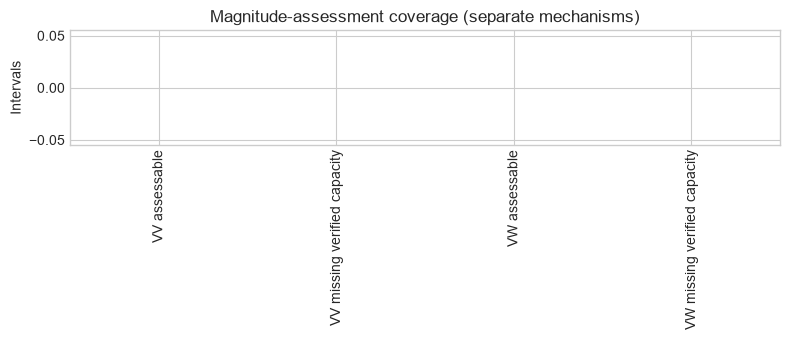

In [10]:
sample_validation = validate_mechanism_results(config, sample_scope)
headline = {k: v for k, v in sample_validation.items() if k not in {'failures', 'monthly_coverage'}}
display(pd.DataFrame([headline]).T.rename(columns={0: 'value'}))
display(pd.DataFrame(sample_validation['monthly_coverage']))
reason_counts = pd.Series({
    'VV assessable': sample_validation['voltvar_assessable_intervals'],
    'VV missing verified capacity': sample_validation['voltvar_capacity_unavailable_intervals'],
    'VW assessable': sample_validation['voltwatt_assessable_intervals'],
    'VW missing verified capacity': sample_validation['voltwatt_capacity_unavailable_intervals'],
})
fig, ax = plt.subplots(figsize=(8, 3.5))
reason_counts.plot.bar(ax=ax, color=['#4472c4','#a5a5a5','#70ad47','#a5a5a5'])
ax.set_ylabel('Intervals')
ax.set_title('Magnitude-assessment coverage (separate mechanisms)')
plt.tight_layout(); plt.show()
assert sample_validation['status'] == 'pass'
assert sample_validation['voltvar_denominator_difference'] == 0
assert sample_validation['voltwatt_denominator_difference'] == 0
assert sample_validation['voltvar_duplicate_keys'] == 0
assert sample_validation['voltwatt_duplicate_keys'] == 0
assert sample_validation['response_duplicate_keys'] == 0


## Optional full-dataset build

Run each cell separately. The full build stays locked until the sign review is recorded in configuration and the deterministic slice passes. With current null `s_rated_kva`, Volt-VAr and Volt-Watt magnitude rows will honestly remain not assessable; response observability can still be populated.


In [11]:
FULL_RUN_CONFIRMATION = 'RUN MECHANISM RESULTS FULL'  # Change to: RUN MECHANISM RESULTS FULL
OVERWRITE_FULL = False
assert sample_validation['status'] == 'pass'
assert SIGN_REVIEW_CONFIRMATION in {'SIGN REVIEW COMPLETE', 'BUILD WITH SIGNS UNVERIFIED'}, (
    'Rerun the Stage 1 sign-review gate cell in this session first.'
)
if SIGN_REVIEW_CONFIRMATION == 'SIGN REVIEW COMPLETE':
    assert mechanism.active_sign_ready and mechanism.reactive_sign_ready
else:
    print(
        "Full build proceeding under 'BUILD WITH SIGNS UNVERIFIED': every sign-dependent row in "
        "the full result tables will be sign_unverified, not assessable."
    )
assert FULL_RUN_CONFIRMATION == 'RUN MECHANISM RESULTS FULL'
full_scope = config.scope(None, None)
print('Full mechanism build unlocked:', full_scope.label)


Full build proceeding under 'BUILD WITH SIGNS UNVERIFIED': every sign-dependent row in the full result tables will be sign_unverified, not assessable.
Full mechanism build unlocked: full


In [12]:
if OVERWRITE_FULL or not voltvar_results_path(config, full_scope).is_file():
    full_vv = build_voltvar_results(config, full_scope, mechanism, overwrite=OVERWRITE_FULL)
    display(pd.DataFrame([full_vv]).T.rename(columns={0: 'value'}))
else:
    print('Reusing full Volt-VAr proxy results.')


Reusing full Volt-VAr proxy results.


In [13]:
if OVERWRITE_FULL or not voltwatt_results_path(config, full_scope).is_file():
    full_vw = build_voltwatt_results(config, full_scope, mechanism, overwrite=OVERWRITE_FULL)
    display(pd.DataFrame([full_vw]).T.rename(columns={0: 'value'}))
else:
    print('Reusing full Volt-Watt proxy results.')


Reusing full Volt-Watt proxy results.


In [14]:
if OVERWRITE_FULL or not response_observability_path(config, full_scope).is_file():
    full_response = build_response_observability(config, full_scope, mechanism, overwrite=OVERWRITE_FULL)
    display(pd.DataFrame([full_response]).T.rename(columns={0: 'value'}))
else:
    print('Reusing full response-observability results.')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,value
created_utc,2026-08-02T02:25:10.110192+00:00
mechanism,response_observability
scope,full
rows,32494
methodology_id,net_meter_proxy__voltage_avg__capacity_s_rated...
measurement_basis,net_meter_proxy
voltage_measurement_location,revenue_meter
capacity_basis,s_rated_kva
formal_inverter_conformance_assessable,False
output,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...


In [15]:
full_validation = validate_mechanism_results(config, full_scope)
display(pd.DataFrame([{k: v for k, v in full_validation.items() if k not in {'failures','monthly_coverage'}}]).T.rename(columns={0: 'value'}))
display(pd.DataFrame(full_validation['monthly_coverage']))
assert full_validation['status'] == 'pass'
assert full_validation['counterfactual_supported_curtailment'] == 'not_built_gate_7_unmet'
print('Full mechanism result build passed structural and methodological validation.')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,value
created_utc,2026-08-02T02:25:35.714989+00:00
scope,full
status,pass
structured_site_rows,140069836
structured_phase_rows,284087739
voltvar_result_rows,122318
voltvar_source_intervals,140069836
voltvar_denominator_difference,0
voltvar_classification_difference,0
voltvar_duplicate_keys,0


,year_utc,month_utc,n_source_intervals,n_voltvar_assessable
0,2024,8,11839849.0,0.0
1,2024,9,11450002.0,0.0
2,2024,10,11881243.0,0.0
3,2024,11,11557950.0,0.0
4,2024,12,11928895.0,0.0
5,2025,1,11927780.0,0.0
6,2025,2,10773504.0,0.0
7,2025,3,11927791.0,0.0
8,2025,4,11384175.0,0.0
9,2025,5,11927808.0,0.0


Full mechanism result build passed structural and methodological validation.


## Phase-scope comparison: all_phases vs der_inferred (optional)

Everything above uses `phase_scope_basis = "der_inferred"` (the default):
comparison voltage, and the summed P/Q, come only from the phase(s)
`site_eligibility.inferred_der_phases` marks as DER-connected for that site
-- which can be 1 of 3 phases.

For a DER genuinely wired to a single phase, that phase's own voltage *is*
its terminal voltage as far as the standard's Volt-Watt/Volt-Var curves are
concerned -- there is no real ambiguity there, since the inverter has no
electrical connection to the other two phases. The genuine open questions
are (a) how a truly multi-phase inverter internally derives one control
voltage from three unbalanced phases -- AS/NZS 4777.2:2020 does not
prescribe this -- and (b) whether `site_eligibility`'s phase-mapping
inference is actually correct for a given site (`phase_mapping_confidence`
is a statistical inference from load signatures, not a confirmed fact).

`phase_scope_basis = "all_phases"` is a deliberate sensitivity/comparison
run, not a claim that the standard requires averaging in phases the DER may
not be connected to: comparison voltage becomes `voltage_mean_valid_v` /
`voltage_max_valid_v` (every phase), and P/Q become `p_export_net_observed_w`
/ `q_absorbing_net_observed_var` (summed over every phase with a power
reading, gated by a recomputed all-phase completeness check so a partial-
phase sum is never silently treated as a verified total). Summing P/Q is
correct under either scope -- that part is just energy accounting, not a
modeling choice; only the voltage aggregation is genuinely a choice.

This section writes to a separate `phase_scope_all_phases/` subfolder --
it never overwrites the der_inferred results already built above, so both
can be inspected side by side. `response_observability.parquet` is not
rebuilt here: it already reports every actual telemetry phase (tagged
`is_inferred_der_phase`), so it does not depend on this setting.

In [ ]:
import dataclasses

mechanism_all_phases = dataclasses.replace(
    mechanism, phase_scope_basis='all_phases'
).validate()
display(pd.Series({
    'methodology_id': mechanism_all_phases.methodology_id,
    'phase_scope_basis': mechanism_all_phases.phase_scope_basis,
    'voltage_basis': mechanism_all_phases.voltage_basis_label,
    'comparison_p_column': mechanism_all_phases.comparison_p_column,
    'comparison_q_absorbing_column': mechanism_all_phases.comparison_q_absorbing_column,
}, name='value').to_frame())
print('Original der_inferred methodology_id (unchanged, still the paths used above):',
      mechanism.methodology_id)

In [ ]:
OVERWRITE_SAMPLE_ALL_PHASES = False
if OVERWRITE_SAMPLE_ALL_PHASES or not voltvar_results_path(config, sample_scope, mechanism_all_phases).is_file():
    display(pd.DataFrame([build_voltvar_results(
        config, sample_scope, mechanism_all_phases, overwrite=OVERWRITE_SAMPLE_ALL_PHASES
    )]).T.rename(columns={0: 'value'}))
if OVERWRITE_SAMPLE_ALL_PHASES or not voltwatt_results_path(config, sample_scope, mechanism_all_phases).is_file():
    display(pd.DataFrame([build_voltwatt_results(
        config, sample_scope, mechanism_all_phases, overwrite=OVERWRITE_SAMPLE_ALL_PHASES
    )]).T.rename(columns={0: 'value'}))

sample_validation_all_phases = validate_mechanism_results(config, sample_scope, mechanism_all_phases)
assert sample_validation_all_phases['status'] == 'pass'
assert sample_validation_all_phases['voltvar_denominator_difference'] == 0
assert sample_validation_all_phases['voltwatt_denominator_difference'] == 0
print('Sample all_phases build validated.')

### Full all_phases build (deliberate opt-in, mirrors the main gate above)

In [ ]:
FULL_RUN_CONFIRMATION_ALL_PHASES = ''  # Change to: RUN MECHANISM RESULTS FULL ALL PHASES
OVERWRITE_FULL_ALL_PHASES = False
assert sample_validation_all_phases['status'] == 'pass'
assert SIGN_REVIEW_CONFIRMATION in {'SIGN REVIEW COMPLETE', 'BUILD WITH SIGNS UNVERIFIED'}
assert FULL_RUN_CONFIRMATION_ALL_PHASES == 'RUN MECHANISM RESULTS FULL ALL PHASES'
print('Full all_phases mechanism build unlocked:', full_scope.label)

In [ ]:
if OVERWRITE_FULL_ALL_PHASES or not voltvar_results_path(config, full_scope, mechanism_all_phases).is_file():
    full_vv_ap = build_voltvar_results(config, full_scope, mechanism_all_phases, overwrite=OVERWRITE_FULL_ALL_PHASES)
    display(pd.DataFrame([full_vv_ap]).T.rename(columns={0: 'value'}))
else:
    print('Reusing full all_phases Volt-VAr proxy results.')

if OVERWRITE_FULL_ALL_PHASES or not voltwatt_results_path(config, full_scope, mechanism_all_phases).is_file():
    full_vw_ap = build_voltwatt_results(config, full_scope, mechanism_all_phases, overwrite=OVERWRITE_FULL_ALL_PHASES)
    display(pd.DataFrame([full_vw_ap]).T.rename(columns={0: 'value'}))
else:
    print('Reusing full all_phases Volt-Watt proxy results.')

full_validation_all_phases = validate_mechanism_results(config, full_scope, mechanism_all_phases)
assert full_validation_all_phases['status'] == 'pass'
print('Full all_phases mechanism build passed structural validation.')

### Side-by-side: der_inferred vs all_phases

Both tables now exist at their own paths. This compares source-interval
counts and top-level denominator/classification totals -- it does not
merge them into a single score (`phase_scope` differs in meaning between
the two, so joining row-for-row on it would be misleading).

In [ ]:
def _totals(path, label):
    df = con.execute(f"SELECT * FROM read_parquet({sql_string(str(path))})").fetchdf()
    numeric = df.select_dtypes('number').sum(numeric_only=True)
    numeric['phase_scope_basis'] = label
    return numeric

con = connect(config)
der_totals = _totals(voltvar_results_path(config, full_scope, mechanism), 'der_inferred')
all_totals = _totals(voltvar_results_path(config, full_scope, mechanism_all_phases), 'all_phases')
con.close()

compare = pd.DataFrame([der_totals, all_totals]).set_index('phase_scope_basis')
display(compare[[c for c in compare.columns if c.startswith('n_')]].T)
print('\nA large gap here is a direct measure of how much the DER-phase mapping '
      'assumption is driving the Volt-VAr result -- not evidence either scope is "correct".')